Размер исходного изображения: (2112, 2816)
Размер исходного бинарного файла: 5947400 байт

Размеры компонент после преобразования Хаара:
LL: (1056, 1408), LH: (1056, 1408), HL: (1056, 1408), HH: (1056, 1408)

Диапазоны значений до квантования:
LH: [-45.50, 53.75]
HL: [-40.25, 34.75]
HH: [-12.00, 11.50]

Диапазоны значений после квантования:
LH: [0, 4]
HL: [0, 4]
HH: [0, 4]
Исходное изображение (бинарный формат): 5947400 байт
После вейвлет-преобразования и RLE: 2973839 байт
Степень сжатия: 2.00
Экономия памяти: 50.00%

Статистика RLE кодирования:
LH: 5 пар
HL: 5 пар
HH: 5 пар
Всего RLE пар: 15


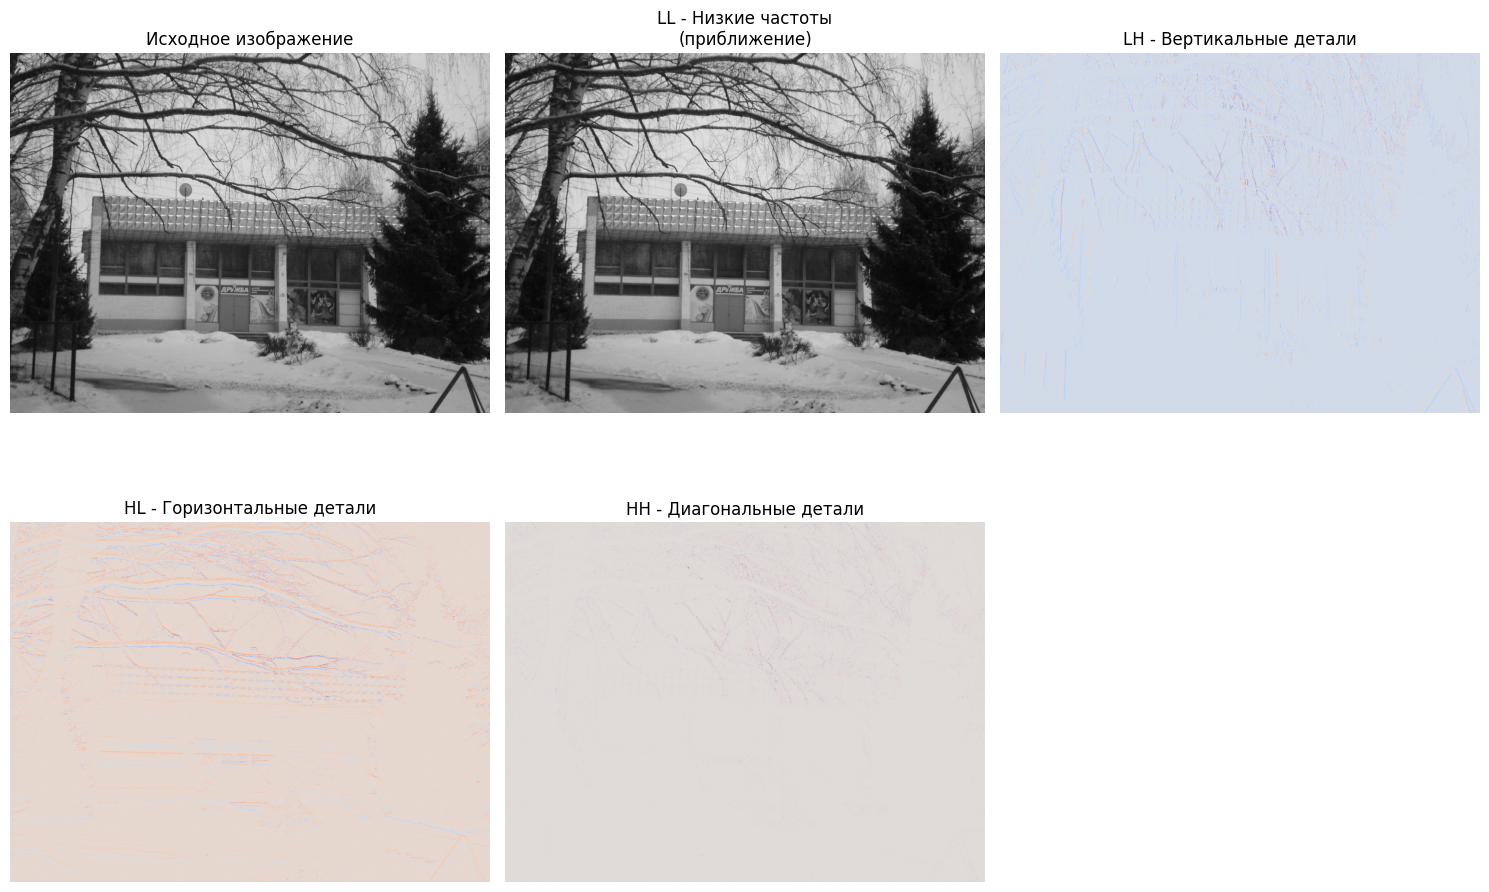

In [2]:
import numpy as np
import cv2
from collections import Counter
import struct
import os
import matplotlib.pyplot as plt

image = cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE)
print(f"Размер исходного изображения: {image.shape}")

height, width = image.shape
if height % 2 != 0:
    image = image[:height-1, :]
if width % 2 != 0:
    image = image[:, :width-1]

def save_monochrome_binary(image, filename):
    height, width = image.shape
    with open(filename, 'wb') as f:
        f.write(struct.pack('II', height, width))
        f.write(image.astype(np.uint8).tobytes())

def load_monochrome_binary(filename):
    with open(filename, 'rb') as f:
        height = struct.unpack('I', f.read(4))[0]
        width = struct.unpack('I', f.read(4))[0]
        data = f.read()
        image = np.frombuffer(data, dtype=np.uint8).reshape(height, width)
    return image

save_monochrome_binary(image, 'original_image.bin')
original_size = os.path.getsize('original_image.bin')
print(f"Размер исходного бинарного файла: {original_size} байт")

def haar_wavelet_transform(image):
    rows, cols = image.shape
    image = image.astype(np.float32)

    row_transform = np.zeros_like(image, dtype=np.float32)
    for i in range(rows):
        for j in range(0, cols - 1, 2):
            row_transform[i, j // 2] = (image[i, j] + image[i, j + 1]) / 2
            row_transform[i, (j // 2) + cols // 2] = (image[i, j] - image[i, j + 1]) / 2

    result = np.zeros_like(row_transform, dtype=np.float32)
    for j in range(cols):
        for i in range(0, rows - 1, 2):
            result[i // 2, j] = (row_transform[i, j] + row_transform[i + 1, j]) / 2
            result[(i // 2) + rows // 2, j] = (row_transform[i, j] - row_transform[i + 1, j]) / 2

    LL = result[:rows // 2, :cols // 2]  
    LH = result[:rows // 2, cols // 2:]  
    HL = result[rows // 2:, :cols // 2]  
    HH = result[rows // 2:, cols // 2:]  
    
    return LL, LH, HL, HH

LL, LH, HL, HH = haar_wavelet_transform(image)
print(f"\nРазмеры компонент после преобразования Хаара:")
print(f"LL: {LL.shape}, LH: {LH.shape}, HL: {HL.shape}, HH: {HH.shape}")

def quantize_coefficients(coeffs, levels=4):
    min_val = np.min(coeffs)
    max_val = np.max(coeffs)
    step = (max_val - min_val) / levels
    quantized = np.round((coeffs - min_val) / step).astype(np.int8)
    return quantized, min_val, step

LH_quantized, LH_min, LH_step = quantize_coefficients(LH, 4)
HL_quantized, HL_min, HL_step = quantize_coefficients(HL, 4)
HH_quantized, HH_min, HH_step = quantize_coefficients(HH, 4)

print(f"\nДиапазоны значений до квантования:")
print(f"LH: [{LH.min():.2f}, {LH.max():.2f}]")
print(f"HL: [{HL.min():.2f}, {HL.max():.2f}]")
print(f"HH: [{HH.min():.2f}, {HH.max():.2f}]")

print(f"\nДиапазоны значений после квантования:")
print(f"LH: [{LH_quantized.min()}, {LH_quantized.max()}]")
print(f"HL: [{HL_quantized.min()}, {HL_quantized.max()}]")
print(f"HH: [{HH_quantized.min()}, {HH_quantized.max()}]")

def run_length_encode(data):
    flattened = data.flatten()
    encoded = []
    for value, count in Counter(flattened).items():
        encoded.append((value, count))
    return encoded

LH_rle = run_length_encode(LH_quantized)
HL_rle = run_length_encode(HL_quantized)
HH_rle = run_length_encode(HH_quantized)

def save_haar_compressed(LL, LH_rle, HL_rle, HH_rle, filename):
    with open(filename, 'wb') as f:
        h, w = LL.shape
        f.write(struct.pack('II', h, w))
        f.write(LL.astype(np.float16).tobytes())
        for rle_data, comp_name in [(LH_rle, 'LH'), (HL_rle, 'HL'), (HH_rle, 'HH')]:
            f.write(struct.pack('B', len(rle_data)))  
            for value, count in rle_data:
                f.write(struct.pack('bI', value, count))  
        f.write(struct.pack('fff', LH_min, LH_step, 0)) 

save_haar_compressed(LL, LH_rle, HL_rle, HH_rle, 'compressed_haar.bin')
compressed_size = os.path.getsize('compressed_haar.bin')

compression_ratio = original_size / compressed_size
space_saving = (1 - compressed_size / original_size) * 100

print(f"Исходное изображение (бинарный формат): {original_size} байт")
print(f"После вейвлет-преобразования и RLE: {compressed_size} байт")
print(f"Степень сжатия: {compression_ratio:.2f}")
print(f"Экономия памяти: {space_saving:.2f}%")
print(f"\nСтатистика RLE кодирования:")
print(f"LH: {len(LH_rle)} пар")
print(f"HL: {len(HL_rle)} пар") 
print(f"HH: {len(HH_rle)} пар")
print(f"Всего RLE пар: {len(LH_rle) + len(HL_rle) + len(HH_rle)}")

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(LL, cmap='gray')
plt.title('LL - Низкие частоты\n(приближение)')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(LH, cmap='coolwarm')
plt.title('LH - Вертикальные детали')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(HL, cmap='coolwarm')
plt.title('HL - Горизонтальные детали')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(HH, cmap='coolwarm')
plt.title('HH - Диагональные детали')
plt.axis('off')

plt.tight_layout()
plt.show()